## Question 1

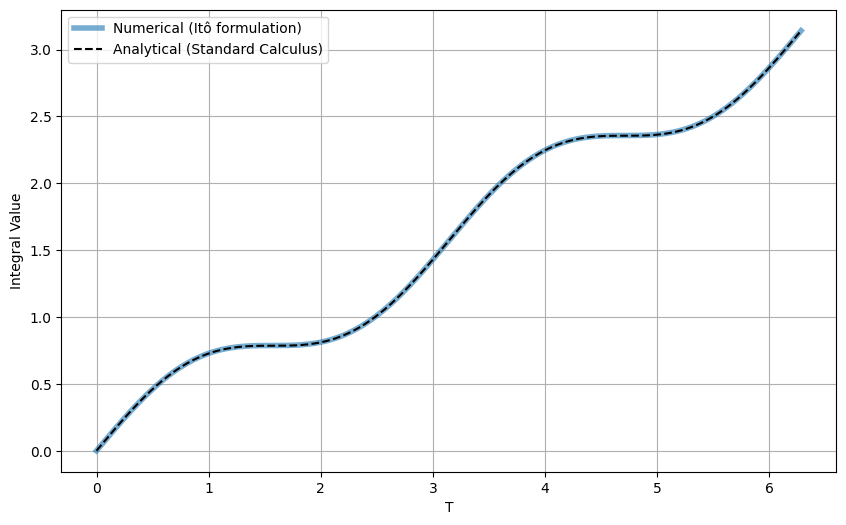

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def ito_integral(G, B):
    return np.concatenate(([0], np.cumsum(G[:-1] * np.diff(B))))

T_grid = np.linspace(0, 2*np.pi, 1000)

G = np.cos(T_grid)
B = np.sin(T_grid)

numerical_result = ito_integral(G, B)

analytical_result = 0.5 * T_grid + 0.25 * np.sin(2 * T_grid)    

plt.figure(figsize=(10, 6))
plt.plot(T_grid, numerical_result, label="Numerical (Itô formulation)", linewidth=4, alpha=0.6)
plt.plot(T_grid, analytical_result, label="Analytical (Standard Calculus)", linestyle='--', color='black')
plt.xlabel("T")
plt.ylabel("Integral Value")
plt.legend()
plt.grid(True)
plt.show()

## Question 2

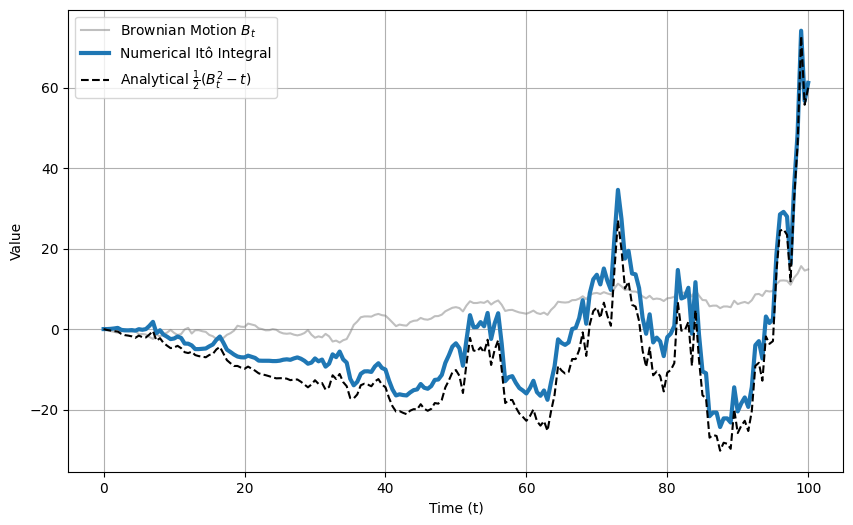

In [23]:
import numpy as np
import matplotlib.pyplot as plt

step_size = 0.5
T_grid = np.arange(0.0, 100.0 + step_size, step_size)
N = len(T_grid)

increments = np.random.normal(loc=0.0, scale=np.sqrt(step_size), size=N-1)
B = np.concatenate(([0], np.cumsum(increments)))
G = B

numerical_result = ito_integral(G, B)
analytical_result = 0.5 * (B**2 - T_grid)

plt.figure(figsize=(10, 6))
plt.plot(T_grid, B, label="Brownian Motion $B_t$", color='gray', alpha=0.5)
plt.plot(T_grid, numerical_result, label="Numerical Itô Integral", linewidth=3)
plt.plot(T_grid, analytical_result, label="Analytical $\\frac{1}{2}(B_t^2 - t)$", linestyle='--', color='black')
plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

## Question 3

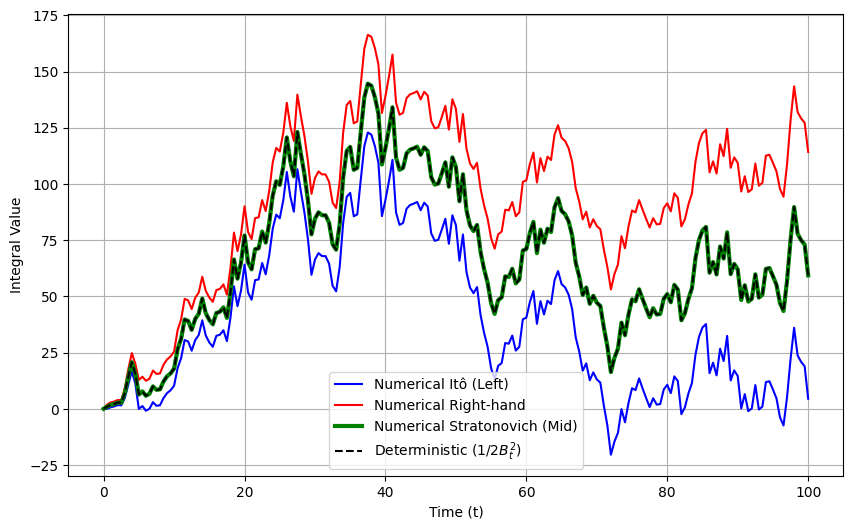

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def ito_integral_right_hand(G, B):
    return np.concatenate(([0], np.cumsum(G[1:] * np.diff(B))))

def stratonovich_integral(G, B):
    return np.concatenate(([0], np.cumsum(0.5 * (G[:-1] + G[1:]) * np.diff(B))))

step_size = 0.5
T_grid = np.arange(0.0, 100.0 + step_size, step_size)
N = len(T_grid)

increments = np.random.normal(loc=0.0, scale=np.sqrt(step_size), size=N-1)
B = np.concatenate(([0], np.cumsum(increments)))
G = B

ito_result = ito_integral(G, B)
right_result = ito_integral_right_hand(G, B)
stratonovich_result = stratonovich_integral(G, B)

analytical_deterministic = 0.5 * B**2

plt.figure(figsize=(10, 6))
plt.plot(T_grid, ito_result, label="Numerical Itô (Left)", color='blue')
plt.plot(T_grid, right_result, label="Numerical Right-hand", color='red')
plt.plot(T_grid, stratonovich_result, label="Numerical Stratonovich (Mid)", color='green', linewidth=3)
plt.plot(T_grid, analytical_deterministic, label="Deterministic ($1/2 B_t^2$)", linestyle='--', color='black')

plt.xlabel("Time (t)")
plt.ylabel("Integral Value")
plt.legend()
plt.grid(True)
plt.show()

## Question 5

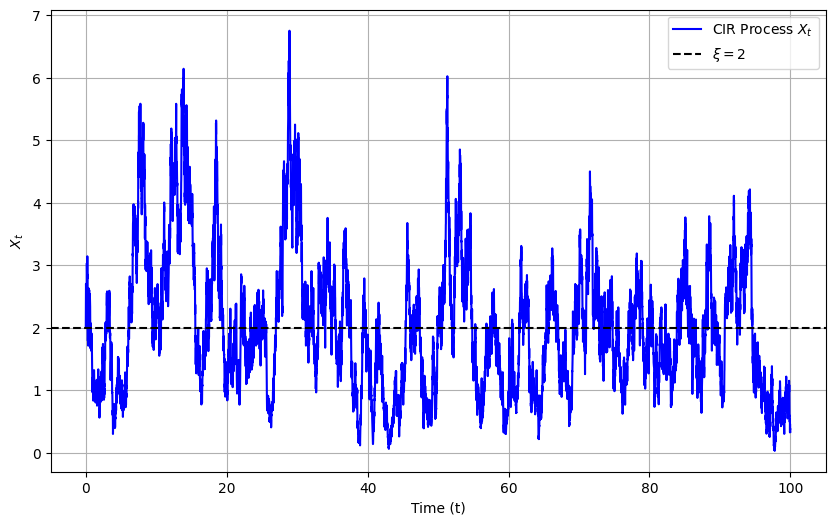

In [27]:
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5
xi = 2.0
gamma = 1.0
h = 0.01
T = 100.0

T_grid = np.arange(0.0, T + h, h)
N = len(T_grid)
X = np.zeros(N)

X[0] = xi

for i in range(N - 1):
    dB = np.random.normal(0, np.sqrt(h))
    X[i + 1] = X[i] + lam * (xi - X[i]) * h + gamma * np.sqrt(np.abs(X[i])) * dB
    
plt.figure(figsize=(10, 6))
plt.plot(T_grid, X, label="CIR Process $X_t$", color='blue', linewidth=1.5)
plt.axhline(y=xi, color='black', linestyle='--', label="$\\xi = 2$")
plt.xlabel("Time (t)")
plt.ylabel("$X_t$")
plt.legend()
plt.grid(True)
plt.show()

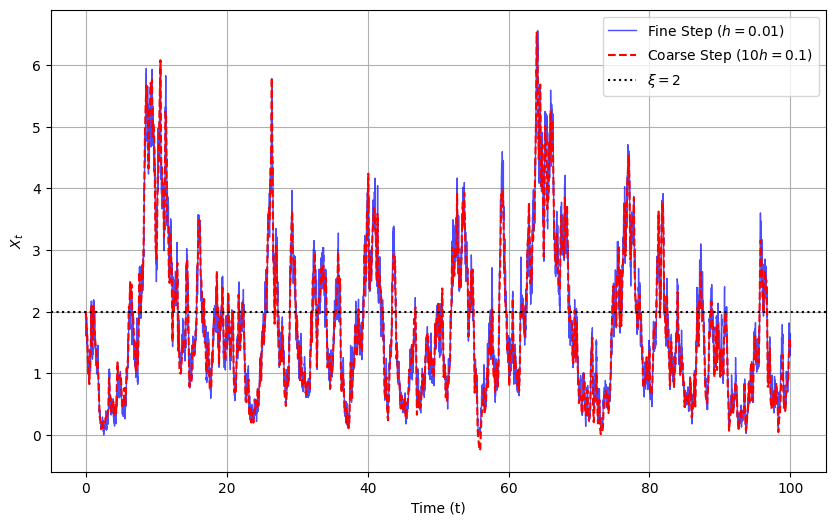

In [30]:
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5
xi = 2.0
gamma = 1.0
h_fine = 0.01
h_coarse = 0.1
T = 100.0

T_grid_fine = np.arange(0.0, T + h_fine, h_fine)
N_fine = len(T_grid_fine)

increments_fine = np.random.normal(0.0, np.sqrt(h_fine), N_fine-1)
B_fine = np.concatenate(([0], np.cumsum(increments_fine)))

T_grid_coarse = T_grid_fine[::10]
B_coarse = B_fine[::10]
N_coarse = len(T_grid_coarse)

X_fine = np.zeros(N_fine)
X_fine[0] = xi
for i in range(N_fine - 1):
    dB = B_fine[i+1] - B_fine[i]
    X_fine[i+1] = X_fine[i] + lam * (xi - X_fine[i]) * h_fine + gamma * np.sqrt(np.abs(X_fine[i])) * dB

X_coarse = np.zeros(N_coarse)
X_coarse[0] = xi
for i in range(N_coarse - 1):
    dB = B_coarse[i+1] - B_coarse[i]
    X_coarse[i+1] = X_coarse[i] + lam * (xi - X_coarse[i]) * h_coarse + gamma * np.sqrt(np.abs(X_coarse[i])) * dB
    
plt.figure(figsize=(10, 6))
plt.plot(T_grid_fine, X_fine, label="Fine Step ($h=0.01$)", color='blue', alpha=0.7, linewidth=1)
plt.plot(T_grid_coarse, X_coarse, label="Coarse Step ($10h=0.1$)", color='red', linestyle='--', linewidth=1.5)
plt.axhline(y=xi, color='black', linestyle=':', label="$\\xi = 2$")
plt.xlabel("Time (t)")
plt.ylabel("$X_t$")
plt.legend()
plt.grid(True)
plt.show()

## Question 7

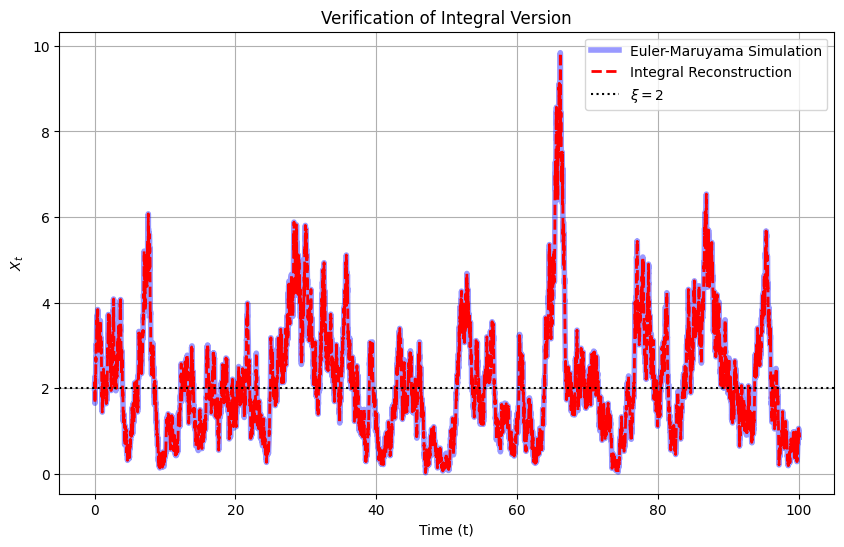

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def ito_integral(G, B):
    return np.concatenate(([0], np.cumsum(G[:-1] * np.diff(B))))

lam = 0.5
xi = 2.0
gamma = 1.0
h_fine = 0.01
h_coarse = 0.1
T = 100.0

T_grid_fine = np.arange(0.0, T + h_fine, h_fine)
N_fine = len(T_grid_fine)

increments_fine = np.random.normal(0.0, np.sqrt(h_fine), N_fine-1)
B_fine = np.concatenate(([0], np.cumsum(increments_fine)))

X_fine = np.zeros(N_fine)
X_fine[0] = xi
for i in range(N_fine - 1):
    dB = B_fine[i+1] - B_fine[i]
    X_fine[i+1] = X_fine[i] + lam * (xi - X_fine[i]) * h_fine + gamma * np.sqrt(np.abs(X_fine[i])) * dB

deterministic_G = lam * (xi - X_fine)
deterministic_integral = ito_integral(deterministic_G, T_grid_fine)

stochastic_G = gamma * np.sqrt(np.abs(X_fine))
stochastic_integral = ito_integral(stochastic_G, B_fine)

X_integral_version = xi + deterministic_integral + stochastic_integral

plt.figure(figsize=(10, 6))
plt.plot(T_grid_fine, X_fine, label="Euler-Maruyama Simulation", color='blue', linewidth=4, alpha=0.4)
plt.plot(T_grid_fine, X_integral_version, label="Integral Reconstruction", color='red', linestyle='--', linewidth=2)

plt.axhline(y=xi, color='black', linestyle=':', label="$\\xi = 2$")
plt.xlabel("Time (t)")
plt.ylabel("$X_t$")
plt.title("Verification of Integral Version")
plt.legend()
plt.grid(True)
plt.show()